In [1]:
import requests
import pandas as pd
import numpy as np
from datetime import date
import matplotlib.pyplot as plt
import os


plt.rc('font', size=18)         # base font
plt.rc('axes', titlesize=18)    # title
plt.rc('axes', labelsize=18)    # x/y labels
plt.rc('xtick', labelsize=14)   # x ticks
plt.rc('ytick', labelsize=14)   # y ticks
plt.rc('legend', fontsize=14)   # legend



Selected numerator: Roofing contractors | series_id: CES2023816001
Selected denominator: Specialty trade contractors | series_id: CES2023800001


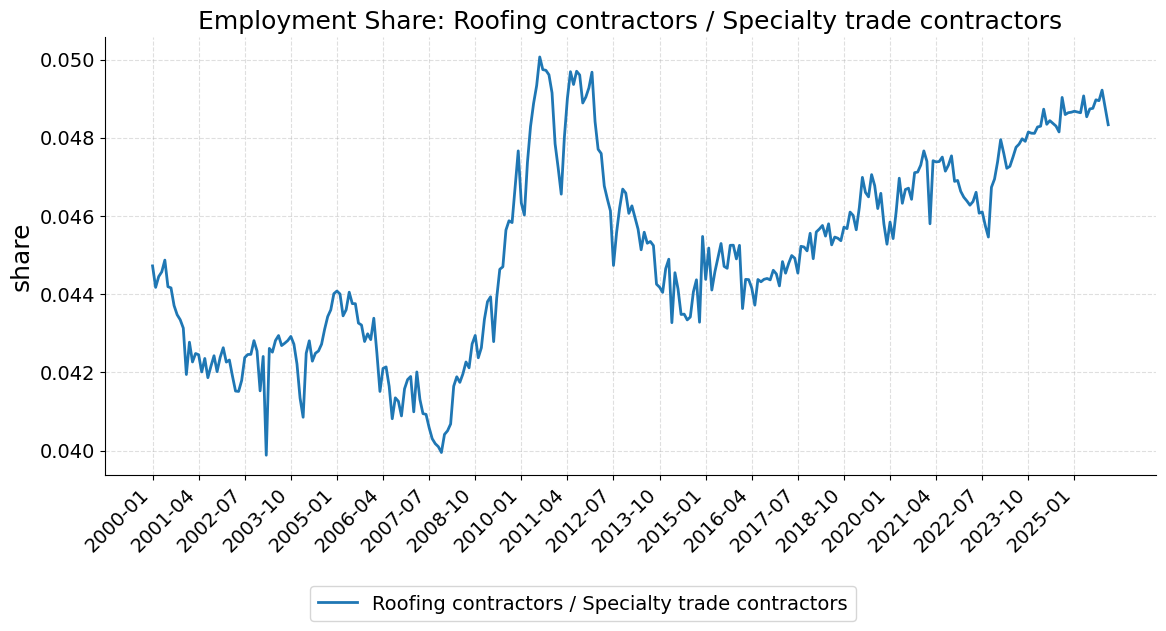

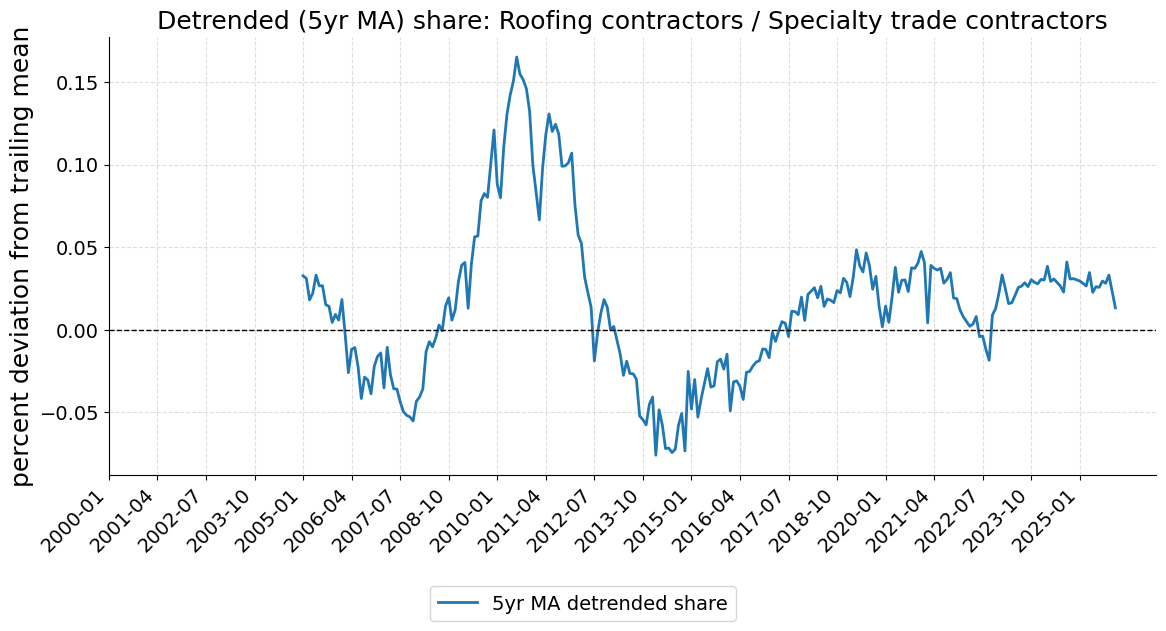

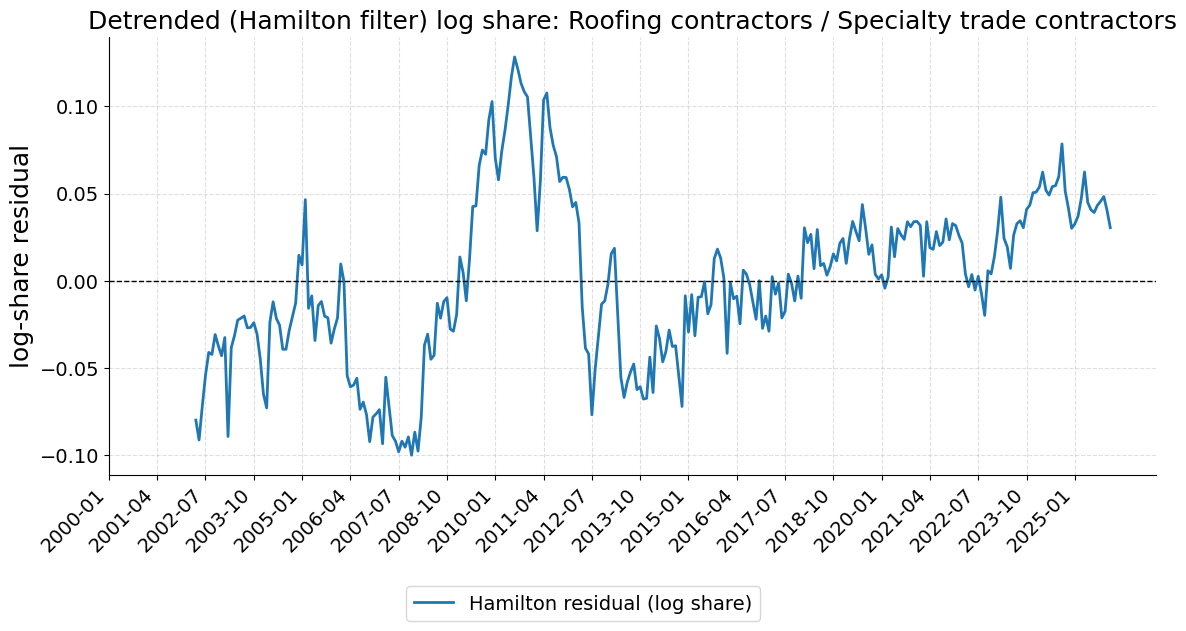

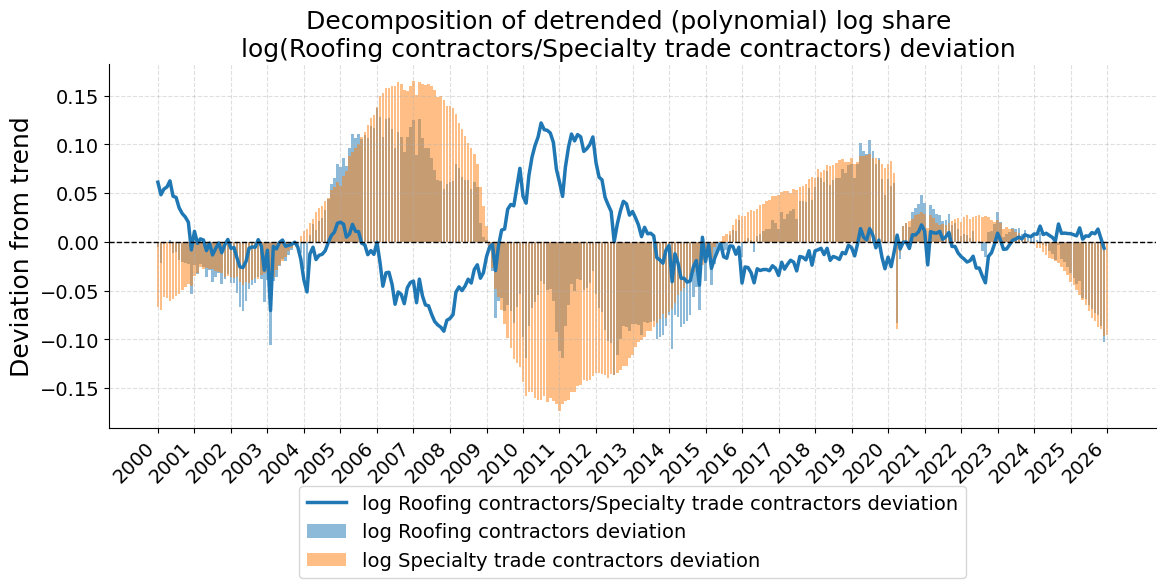

Saved export CSV to: graphs/CES2023816001_share_and_detrended_export.csv
Saved PDFs to: graphs


In [6]:

# -----------------------
# Paths / files
# -----------------------
MAP_PATH = "b1a_mapping_with_parent.csv"   # must include: series_id, parent_series_id, industry_name
OUT_DIR = "graphs"
DETRENDED_DIR = "detrended"

# Employment level panel (date x series_id). Use whichever you have.
EMP_PQ = "b1a_wide_seriesid.parquet"
EMP_CSV = "b1a_wide_seriesid.csv"

# Shares panel (date x series_id)
SHARES_CSV = "b1a_employment_shares.csv"

# Detrended shares (date x series_id), moved to DETRENDED_DIR
DET1_CSV = os.path.join(DETRENDED_DIR, "detrended_share_ma60.csv")
DET2_CSV = os.path.join(DETRENDED_DIR, "detrended_share_hamilton_logshare.csv")
DET3_CSV = os.path.join(DETRENDED_DIR, "detrended_share_poly3_logempdiff.csv")

# Detrended log employment residuals (date x series_id) from option 3 intermediate
LOGEMP_DET_CSV = os.path.join(DETRENDED_DIR, "detrended_logemp.csv")


os.makedirs(OUT_DIR, exist_ok=True)


# -----------------------
# Helpers
# -----------------------
def load_panel(path_csv, index_col=0):
    df = pd.read_csv(path_csv, index_col=index_col, parse_dates=True)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors="coerce")
    return df.sort_index()

def load_employment_panel():
    if os.path.exists(EMP_PQ):
        df = pd.read_parquet(EMP_PQ)
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index, errors="coerce")
        return df.sort_index()
    if os.path.exists(EMP_CSV):
        return load_panel(EMP_CSV)
    raise FileNotFoundError(f"Could not find employment panel at {EMP_PQ} or {EMP_CSV}")

def find_series_by_industry_name(mapping: pd.DataFrame, industry_name: str) -> tuple[str, str]:
    """
    Returns (series_id, parent_series_id) for a given industry_name.
    Uses exact match first; if not found, case-insensitive trimmed match.
    """
    # exact
    hit = mapping[mapping["industry_name"] == industry_name]
    if hit.empty:
        # case-insensitive
        key = industry_name.strip().lower()
        hit = mapping[mapping["industry_name"].astype(str).str.strip().str.lower() == key]

    if hit.empty:
        raise ValueError(f"industry_name not found in mapping: {industry_name}")

    # If duplicates, take the first by row_order if present, else first row
    if "row_order" in hit.columns:
        hit = hit.copy()
        hit["row_order_num"] = pd.to_numeric(hit["row_order"], errors="coerce")
        hit = hit.sort_values("row_order_num")
    row = hit.iloc[0]
    sid = str(row["series_id"]).strip()
    pid = str(row["parent_series_id"]).strip()
    return sid, pid

def industry_name_for_series(mapping: pd.DataFrame, series_id: str) -> str:
    hit = mapping[mapping["series_id"].astype(str).str.strip() == str(series_id).strip()]
    if hit.empty:
        return series_id
    # prefer first by row_order
    if "row_order" in hit.columns:
        tmp = hit.copy()
        tmp["row_order_num"] = pd.to_numeric(tmp["row_order"], errors="coerce")
        tmp = tmp.sort_values("row_order_num")
        return str(tmp.iloc[0]["industry_name"])
    return str(hit.iloc[0]["industry_name"])

def make_time_ticks(dates: pd.DatetimeIndex, max_labels=20):
    x = np.arange(len(dates))
    labels = pd.Series(dates.strftime("%Y-%m"))
    step = max(1, len(labels) // max_labels)
    tick_idx = np.arange(0, len(labels), step)
    return x, labels, tick_idx

def plot_single_line(dates, y, title, ylabel, legend_label, outpath_pdf, add_zero_line=False):
    x, labels, tick_idx = make_time_ticks(dates, max_labels=20)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x, y.values, linewidth=2, label=legend_label)

    # Add zero line ONLY if requested
    if add_zero_line:
        ax.axhline(0, color="black", linestyle="--", linewidth=1)

    ax.set_title(title)
    ax.set_ylabel(ylabel)

    ax.set_xticks(tick_idx)
    ax.set_xticklabels(labels.iloc[tick_idx], rotation=45, ha="right")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.4)

    fig.legend(bbox_to_anchor=(0.5, -0.08), loc="lower center", ncols=1)
    plt.tight_layout()
    plt.savefig(outpath_pdf, bbox_inches="tight")
    plt.show()

def plot_decomposition_bars_line(dates, num_dev, den_dev, share_dev, title, outpath_pdf,
                                num_label="log numerator deviation",
                                den_label="log denominator deviation",
                                share_label="log share deviation"):
    """
    Bars: numerator deviation (positive as-is)
    Bars: denominator deviation (as-is; if you want it forced negative, pass -den_dev)
    Line: share_dev = num_dev - den_dev
    """
    # Use timestamps directly; make bar width ~ 25 days for monthly-ish spacing
    x_dates = pd.to_datetime(dates)

    fig, ax = plt.subplots(figsize=(12, 7))

    ax.bar(
        x_dates,
        num_dev.values,
        width=25,
        alpha=0.5,
        label=num_label
    )

    ax.bar(
        x_dates,
        den_dev.values,
        width=25,
        alpha=0.5,
        label=den_label
    )

    ax.plot(
        x_dates,
        share_dev.values,
        linewidth=2.5,
        label=share_label
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    ax.set_title(title)
    ax.set_ylabel("Deviation from trend")

    years = pd.date_range(start=x_dates.min(), end=x_dates.max(), freq="YS")
    ax.set_xticks(years)
    ax.set_xticklabels([d.year for d in years], rotation=45, ha="right")

    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(bbox_to_anchor=(0.5, -0.44), loc="lower center", ncols=1)
    plt.tight_layout()
    plt.savefig(outpath_pdf, bbox_inches="tight")
    plt.show()


# -----------------------
# Main plotting + export
# -----------------------
def plot_and_export(industry_name: str):
    # Load mapping
    mapping = pd.read_csv(MAP_PATH, dtype=str)
    mapping.columns = mapping.columns.str.strip()

    # Identify numerator + denominator series
    sid, pid = find_series_by_industry_name(mapping, industry_name)
    denom_name = industry_name_for_series(mapping, pid)
    num_name = industry_name_for_series(mapping, sid)

    print("Selected numerator:", num_name, "| series_id:", sid)
    print("Selected denominator:", denom_name, "| series_id:", pid)

    # Load panels
    emp = load_employment_panel()
    shares = load_panel(SHARES_CSV)

    det1 = load_panel(DET1_CSV)
    det2 = load_panel(DET2_CSV)
    det3 = load_panel(DET3_CSV)
    logemp_det = load_panel(LOGEMP_DET_CSV)

    # Align on common dates
    common_idx = emp.index
    for df in [shares, det1, det2, det3, logemp_det]:
        common_idx = common_idx.intersection(df.index)

    # Pull series
    for df, nm in [(emp, "emp"), (shares, "shares"), (det1, "det1"), (det2, "det2"), (det3, "det3"), (logemp_det, "logemp_det")]:
        if sid not in df.columns:
            raise KeyError(f"{nm} is missing numerator series_id {sid}")
    for df, nm in [(emp, "emp"), (logemp_det, "logemp_det")]:
        if pid not in df.columns:
            raise KeyError(f"{nm} is missing denominator series_id {pid}")
    # Note: shares/det* are by numerator columns; denominator isn't a column there.

    emp_num = emp.loc[common_idx, sid].astype(float)
    emp_den = emp.loc[common_idx, pid].astype(float)

    share_series = shares.loc[common_idx, sid].astype(float)
    d1 = det1.loc[common_idx, sid].astype(float)
    d2 = det2.loc[common_idx, sid].astype(float)
    d3 = det3.loc[common_idx, sid].astype(float)

    num_logdev = logemp_det.loc[common_idx, sid].astype(float)
    den_logdev = logemp_det.loc[common_idx, pid].astype(float)
    share_from_components = num_logdev - den_logdev  # should match detrended_poly3 if constructed that way

    # ----------------------------
    # Graph 1: Share
    # ----------------------------
    title1 = f"Employment Share: {num_name} / {denom_name}"
    out1 = os.path.join(OUT_DIR, f"{sid}_share.pdf")
    plot_single_line(
        dates=common_idx,
        y=share_series,
        title=title1,
        ylabel="share",
        legend_label=f"{num_name} / {denom_name}",
        outpath_pdf=out1,
        add_zero_line=False
    )

    # ----------------------------
    # Graph 2: Detrended share Method 1 (MA60)
    # ----------------------------
    title2 = f"Detrended (5yr MA) share: {num_name} / {denom_name}"
    out2 = os.path.join(OUT_DIR, f"{sid}_detrended_ma60.pdf")
    plot_single_line(
        dates=common_idx,
        y=d1,
        title=title2,
        ylabel="percent deviation from trailing mean",
        legend_label="5yr MA detrended share",
        outpath_pdf=out2,
        add_zero_line=True
    )

    # ----------------------------
    # Graph 3: Detrended share Method 2 (Hamilton)
    # ----------------------------
    title3 = f"Detrended (Hamilton filter) log share: {num_name} / {denom_name}"
    out3 = os.path.join(OUT_DIR, f"{sid}_detrended_hamilton.pdf")
    plot_single_line(
        dates=common_idx,
        y=d2,
        title=title3,
        ylabel="log-share residual",
        legend_label="Hamilton residual (log share)",
        outpath_pdf=out3,
        add_zero_line=True
    )

    # ----------------------------
    # Graph 4: Method 3 decomposition (numerator + denominator + difference)
    # Bars: numerator log deviation (as-is)
    # Bars: denominator log deviation (often helpful to plot as negative; choose your preference below)
    # ----------------------------
    # If you want denominator bars forced negative like your example, use: den_for_plot = -den_logdev
    den_for_plot = den_logdev

    title4 = (
        f"Decomposition of detrended (polynomial) log share \n"
        f"log({num_name}/{denom_name}) deviation "
    )
    out4 = os.path.join(OUT_DIR, f"{sid}_detrended_poly3_decomposition.pdf")
    plot_decomposition_bars_line(
        dates=common_idx,
        num_dev=num_logdev,
        den_dev=den_for_plot,
        share_dev=share_from_components,
        title=title4,
        outpath_pdf=out4,
        num_label=f"log {num_name} deviation",
        den_label=f"log {denom_name} deviation",
        share_label=f"log {num_name}/{denom_name} deviation"
    )

    # ----------------------------
    # Export CSV with requested columns
    # 1) numerator original emp number
    # 2) denominator original emp number
    # 3) detrended share method 1,2,3
    # 4) numerator + denominator detrended log employment (poly3 residuals)
    # ----------------------------
    out_df = pd.DataFrame(
        {
            "numerator_series_id": sid,
            "denominator_series_id": pid,
            "numerator_name": num_name,
            "denominator_name": denom_name,
            "emp_numerator": emp_num,
            "emp_denominator": emp_den,
            "share": share_series,
            "detrended_share_ma60": d1,
            "detrended_share_hamilton_logshare": d2,
            "detrended_share_poly3_logempdiff": d3,
            "detrended_log_emp_numerator_poly3": num_logdev,
            "detrended_log_emp_denominator_poly3": den_logdev
        },
        index=common_idx
    )

    out_csv = os.path.join(OUT_DIR, f"{sid}_share_and_detrended_export.csv")
    out_df.to_csv(out_csv)
    print(f"Saved export CSV to: {out_csv}")
    print(f"Saved PDFs to: {OUT_DIR}")


# -----------------------
# Usage
# -----------------------

plot_and_export("Roofing contractors")
